In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from multicam.multicam import MultiCAM
from multicam.qt import qt
from scipy.stats import spearmanr

from astropy.table import Table

from multicam_tng.utils import generate_randoms
from halotools.mock_observables import return_xyz_formatted_array, tpcf_jackknife, tpcf


In [2]:
TNG_H = 0.6774
COLOR_CUT = 1.0

In [3]:
# mass cut stellar mass
np.log10(1.4e6 * 100 * TNG_H)

np.float64(7.97697322798685)

In [32]:
# load data
_hydro_raw = Table.read("../../data/hydro_final.ecsv")
flag = _hydro_raw["SubhaloFlag"]
hydro_raw = _hydro_raw[flag == 1]
len(hydro_raw)

101364

In [33]:
# Stellar mass cut
# NOTE: this cut can potentially bias the results so we avoid it
# although Ismael and Phil checked that it does not really matter.
# hydro_full = hydro_full[
#     hydro_full['StellarMass'] >= (1.4e8 * TNG_H)
# ]

# Add z12
hydro_raw["z12"] = (1 / hydro_raw["a12"]) - 1

In [34]:
# want to apply mpeak cut first to avoid applying SHAM on low resolution objects
log_mpeak = np.log10(hydro_raw["mpeak"])
mpeak_cut_mask = log_mpeak > 11
hydro_high = hydro_raw[mpeak_cut_mask]
len(hydro_high)


12652

In [35]:
# some below resolution limit but lower end does not matter too much
sum(np.log10(hydro_high["stellar_mass"]) < 7.97)

np.int64(45)

In [36]:
# apply SHAM
x = np.log10(hydro_high["mpeak"].data)
y = np.log10(hydro_high["stellar_mass"].data)

# SHAM mean relation (NO scatter), also defines SHMR
logmstar_sham_high = qt(x, y)

In [37]:
# NOTE: we apply mpeak cut in the "true" stellar mass bin catalog too
# the reasoning here is the we want to consistently apply the cut in our entire sample of haloes
# to avoid resolution effect. We cannot do the resolution cut explicitly because that would
# bias our results (cut on dependent variable)
x1 = np.log10(hydro_raw["stellar_mass"])
x2 = np.log10(hydro_raw["mpeak"])
star_mask = (x1 > 9.5) & (x1 < 10.2) & (x2 > 11)
hydro_mstar_cut = hydro_raw[star_mask]

# get sham stellar mass bin predicted catalog
sham_mask = (logmstar_sham_high > 9.5) & (logmstar_sham_high < 10.2)
hydro_sham = hydro_high[sham_mask]


len(hydro_mstar_cut), len(hydro_sham)

(4050, 4050)

In [38]:
# CAM prediction for color
_color = hydro_mstar_cut["color"]  # NOTE: need to use TRUTH here.
color_cam_pred = qt(hydro_sham["z12"].data, _color)
color_cam_pred.shape

(4050,)

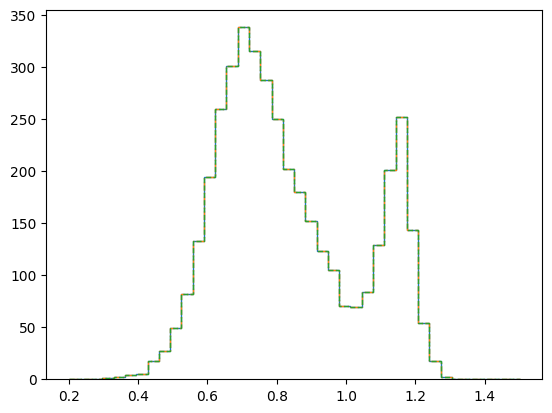

In [39]:
bins = np.linspace(0.2, 1.5, 41)

plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step")
plt.hist(color_cam_pred, bins=bins, histtype="step", linestyle="-.")
plt.hist(_color, bins=bins, histtype="step", linestyle="--");
# shoudl be exactly the same

## Clustering (CAM)

In [40]:
Lbox = 110.7 * TNG_H  # TNG box size in Mpc /h
rbins = np.logspace(np.log10(0.1), np.log10(24.9), 16)
rbin_centers = 0.5 * (rbins[1:] + rbins[:-1])
randoms = generate_randoms(lbox=Lbox, n_randoms=50_000, rng=41)
randoms.shape

(50000, 3)

In [41]:
red_pred = hydro_sham[color_cam_pred > COLOR_CUT]
blue_pred = hydro_sham[color_cam_pred <= COLOR_CUT]

true_color = hydro_mstar_cut["color"]
red_true = hydro_mstar_cut[true_color > COLOR_CUT]
blue_true = hydro_mstar_cut[true_color <= COLOR_CUT]


In [42]:
xyz_red = return_xyz_formatted_array(
    red_true["x"].data, red_true["y"].data, red_true["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_true["x"].data, blue_true["y"].data, blue_true["z"].data
)


xi_red_true = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_true = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


In [43]:
xyz_red = return_xyz_formatted_array(
    red_pred["x"].data, red_pred["y"].data, red_pred["z"].data
)
xyz_blue = return_xyz_formatted_array(
    blue_pred["x"].data, blue_pred["y"].data, blue_pred["z"].data
)


xi_red_cam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_cam = tpcf(xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max")


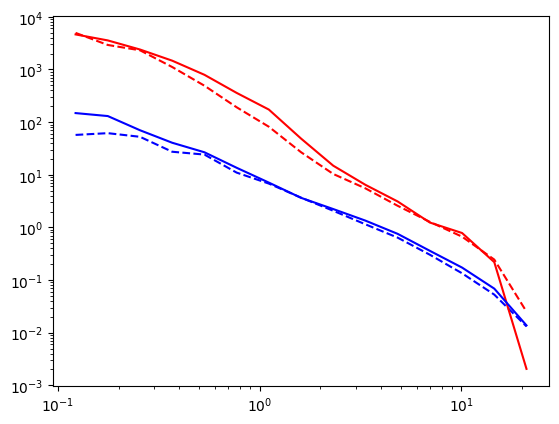

In [44]:
plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--")

plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b")

(0.2, 2.0)

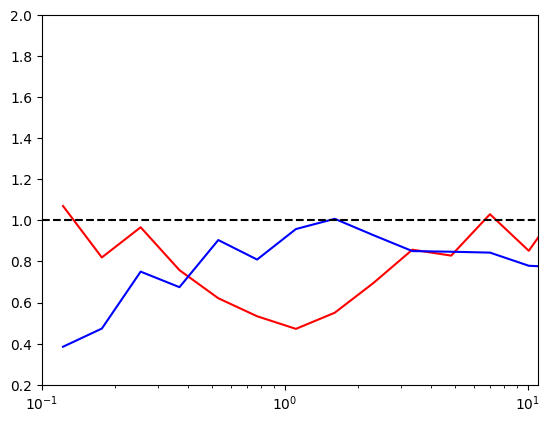

In [45]:
plt.semilogx(rbin_centers, xi_red_cam / xi_red_true, c="r", ls="-")
plt.semilogx(rbin_centers, xi_blue_cam / xi_blue_true, c="b", ls="-")

plt.axhline(1.0, ls="--", c="k")

plt.xlim(0.1, 11)
plt.ylim(0.2, 2.0)

# i think this reproduces haley's results
# doesn't seem to get much affected by adding scatter or not...
# NOTE: double check, but mpeak mass bin cut at the beginning does not seem to affect output

## Repeat with MultiCAM a_{1/2} only

In [46]:
# MultiCAM needs to be trained on the full dataset
# hydro_sham and hydro_mstar_cut are NOT MATCHED, which means that we cannot do linear regression
# with these arrays!
from multicam_tng.multicam2 import multicam_new_prediction_repeats

# can only train multicam on mpeak mass bin
_x = np.log10(hydro_raw["mpeak"])
mask = (_x > 11) & (_x < 12)
hydro_mpeak = hydro_raw[mask]

x_train = hydro_mpeak["a12"].reshape(-1, 1)
y_train = hydro_mpeak["color"].reshape(-1, 1)
y_true = hydro_mstar_cut["color"].reshape(-1, 1)
x_test = hydro_sham["a12"].reshape(-1, 1)

multicam_color_pred = multicam_new_prediction_repeats(
    x_test, x_train=x_train, y_train=y_train, y_true=y_true
)[:, 0]
multicam_color_pred.shape


(4050,)

(array([  0.,   0.,   0.,   1.,   2.,   4.,   5.,  18.,  27.,  49.,  82.,
        133., 194., 260., 301., 338., 315., 287., 250., 202., 180., 152.,
        123., 105.,  70.,  69.,  84., 129., 201., 252., 143.,  54.,  18.,
          2.,   0.,   0.,   0.,   0.,   0.,   0.]),
 array([0.2   , 0.2325, 0.265 , 0.2975, 0.33  , 0.3625, 0.395 , 0.4275,
        0.46  , 0.4925, 0.525 , 0.5575, 0.59  , 0.6225, 0.655 , 0.6875,
        0.72  , 0.7525, 0.785 , 0.8175, 0.85  , 0.8825, 0.915 , 0.9475,
        0.98  , 1.0125, 1.045 , 1.0775, 1.11  , 1.1425, 1.175 , 1.2075,
        1.24  , 1.2725, 1.305 , 1.3375, 1.37  , 1.4025, 1.435 , 1.4675,
        1.5   ]),
 [<matplotlib.patches.Polygon at 0x1186d9310>])

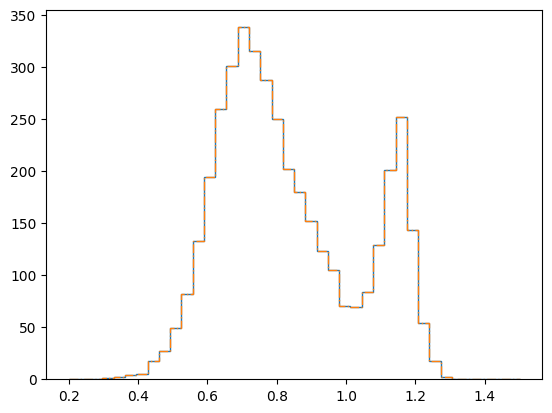

In [47]:
# color distribution should match with (a_1/2 as low number of repeats)
bins = np.linspace(0.2, 1.5, 41)

plt.hist(hydro_mstar_cut["color"], bins=bins, histtype="step")
plt.hist(multicam_color_pred, bins=bins, histtype="step", linestyle="-.")
# shoudl be exactly the same

In [48]:
multicam_red_pred = hydro_sham[multicam_color_pred > COLOR_CUT]
multicam_blue_pred = hydro_sham[multicam_color_pred <= COLOR_CUT]

SignificanceResult(statistic=np.float64(1.0), pvalue=np.float64(0.0))

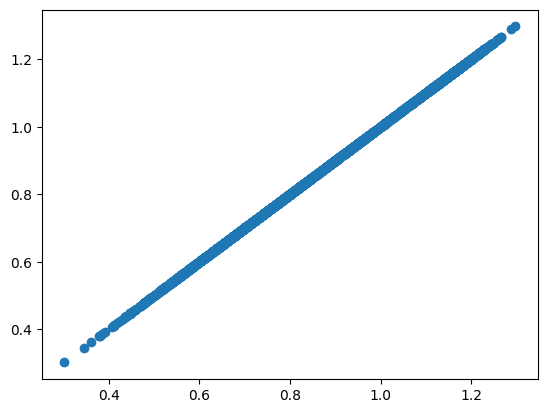

In [49]:
# exactly the same as CAM
plt.plot(multicam_color_pred, color_cam_pred, "o")
spearmanr(color_cam_pred, multicam_color_pred)

In [50]:
xyz_red = return_xyz_formatted_array(
    multicam_red_pred["x"].data,
    multicam_red_pred["y"].data,
    multicam_red_pred["z"].data,
)
xyz_blue = return_xyz_formatted_array(
    multicam_blue_pred["x"].data,
    multicam_blue_pred["y"].data,
    multicam_blue_pred["z"].data,
)


xi_red_multicam = tpcf(xyz_red, rbins, randoms=randoms, period=Lbox, num_threads="max")

xi_blue_multicam = tpcf(
    xyz_blue, rbins, randoms=randoms, period=Lbox, num_threads="max"
)


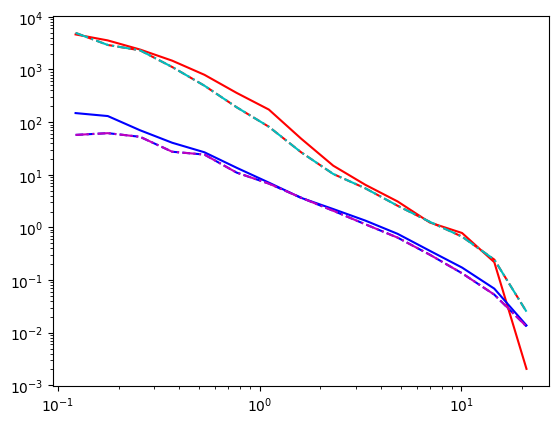

In [51]:
plt.loglog(rbin_centers, xi_red_cam, c="r", ls="--")
plt.loglog(rbin_centers, xi_blue_cam, c="b", ls="--")

plt.loglog(rbin_centers, xi_red_true, c="r")
plt.loglog(rbin_centers, xi_blue_true, c="b")

plt.loglog(rbin_centers, xi_red_multicam, c="c", ls="-.")
plt.loglog(rbin_centers, xi_blue_multicam, c="m", ls="-.")